In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Prétraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)

# Modèle
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

# Rééquilibrage
from sklearn.utils import resample

# Configuration des plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

RANDOM_STATE = 42

---
## 2. Chargement des Données

In [2]:
path = '/content/drive/MyDrive/s6/Fraud Detection Dataset.csv'

In [4]:
df = pd.read_csv(path)
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [7]:
print(f' Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\n Colonnes : {df.columns.tolist()}')


 Dimensions : 51,000 lignes × 12 colonnes

 Colonnes : ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


In [8]:
print('Types de données :')
print(df.dtypes)

Types de données :
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object


In [9]:
print('\n Statistiques descriptives :')
df.describe(include='all')


 Statistiques descriptives :


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,51000,51000.000000,48480.000000,51000,48448.000000,48527,48453,51000.000000,51000.000000,51000.000000,48531,51000.000000
unique,50000,NaN,NaN,5,NaN,4,8,NaN,NaN,NaN,5,NaN
top,T49147,NaN,NaN,Bill Payment,NaN,Desktop,Boston,NaN,NaN,NaN,UPI,NaN
freq,2,NaN,NaN,10340,NaN,15795,6149,NaN,NaN,NaN,11887,NaN
mean,NaN,3005.110176,2996.249784,NaN,11.488400,NaN,NaN,1.995725,60.033902,7.495588,NaN,0.049216
std,NaN,1153.121107,5043.932555,NaN,6.922954,NaN,NaN,1.415150,34.384131,4.020080,NaN,0.216320
min,NaN,1000.000000,5.030000,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,2007.000000,1270.552500,NaN,5.000000,NaN,NaN,1.000000,30.000000,4.000000,NaN,0.000000
50%,NaN,2996.000000,2524.100000,NaN,12.000000,NaN,NaN,2.000000,60.000000,7.000000,NaN,0.000000
75%,NaN,4006.000000,3787.240000,NaN,17.000000,NaN,NaN,3.000000,90.000000,11.000000,NaN,0.000000


---
##  3. Analyse Exploratoire des Données (EDA)

🔍 Valeurs manquantes par colonne :
                     Manquants  Pourcentage (%)
Transaction_Amount        2520             4.94
Time_of_Transaction       2552             5.00
Device_Used               2473             4.85
Location                  2547             4.99
Payment_Method            2469             4.84


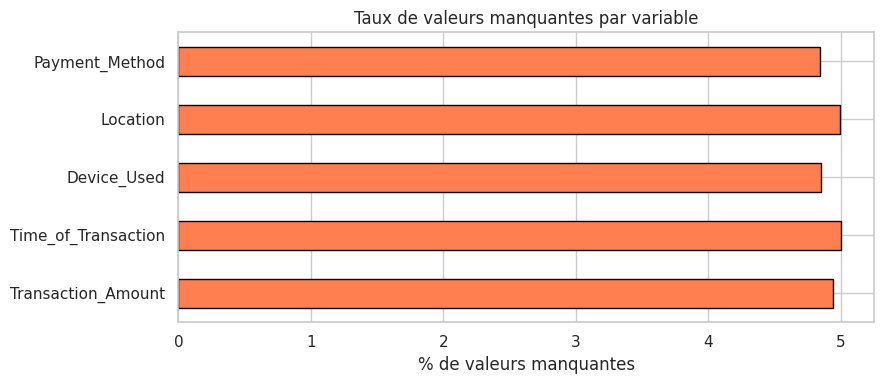

In [10]:
# ──────────────────────────────────────────────
# 3.1 Valeurs manquantes
# ──────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0]

print('🔍 Valeurs manquantes par colonne :')
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 4))
missing_df['Pourcentage (%)'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de valeurs manquantes par variable')
plt.tight_layout()
plt.show()

 Distribution de la cible (Fraudulent) :
  Classe 0: 48,490 (95.08%)
  Classe 1: 2,510 (4.92%)


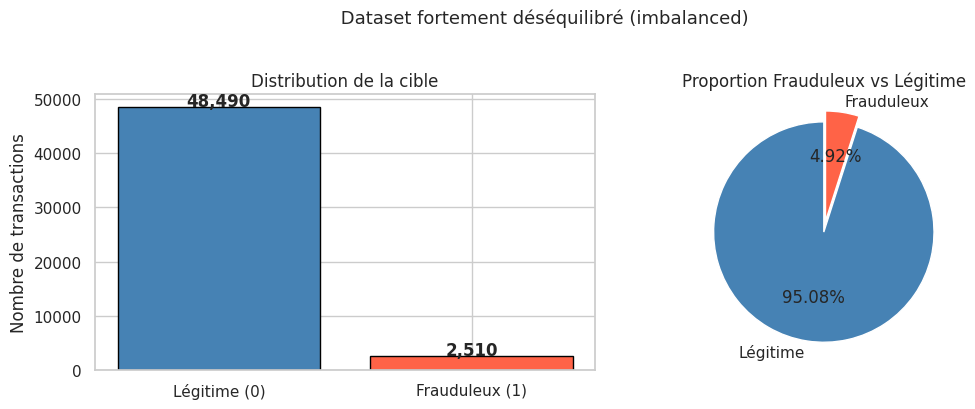

In [12]:
# ──────────────────────────────────────────────
# 3.2 Distribution de la variable cible
# ──────────────────────────────────────────────
target_counts = df['Fraudulent'].value_counts()
target_pct = df['Fraudulent'].value_counts(normalize=True) * 100

print(' Distribution de la cible (Fraudulent) :')
for label, count, pct in zip([0,1], target_counts, target_pct):
    print(f'  Classe {label}: {count:,} ({pct:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Légitime (0)', 'Frauduleux (1)'], target_counts,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribution de la cible')
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts, labels=['Légitime', 'Frauduleux'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Proportion Frauduleux vs Légitime')

plt.suptitle(' Dataset fortement déséquilibré (imbalanced)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

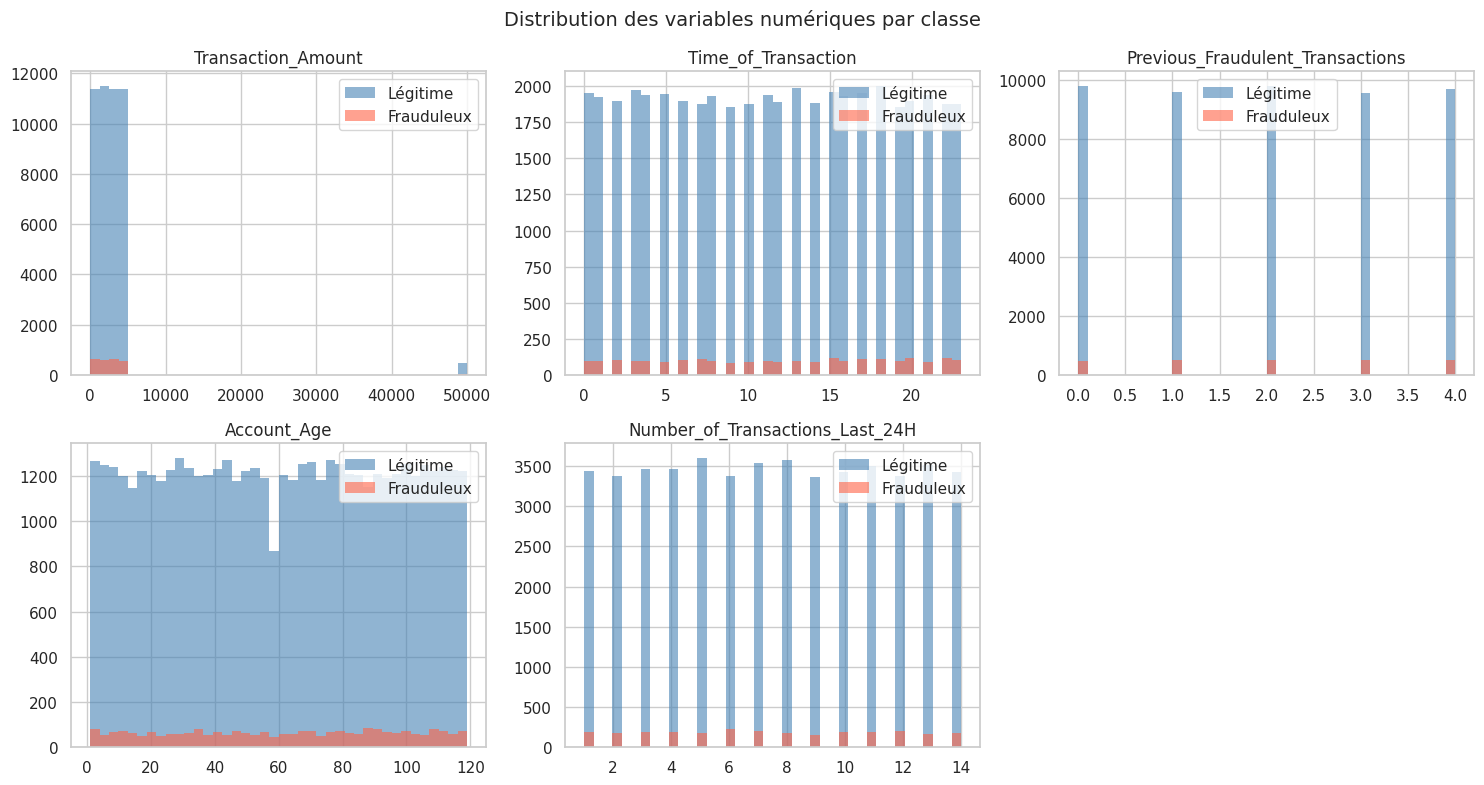

In [13]:
# ──────────────────────────────────────────────
# 3.3 Distribution des variables numériques
# ──────────────────────────────────────────────
num_cols = ['Transaction_Amount', 'Time_of_Transaction',
            'Previous_Fraudulent_Transactions', 'Account_Age',
            'Number_of_Transactions_Last_24H']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls, color, label in zip([0, 1], ['steelblue', 'tomato'], ['Légitime', 'Frauduleux']):
        axes[i].hist(df[df['Fraudulent'] == cls][col].dropna(),
                     bins=40, alpha=0.6, color=color, label=label, edgecolor='none')
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_xlabel('')

axes[5].axis('off')
plt.suptitle('Distribution des variables numériques par classe', fontsize=14)
plt.tight_layout()
plt.show()

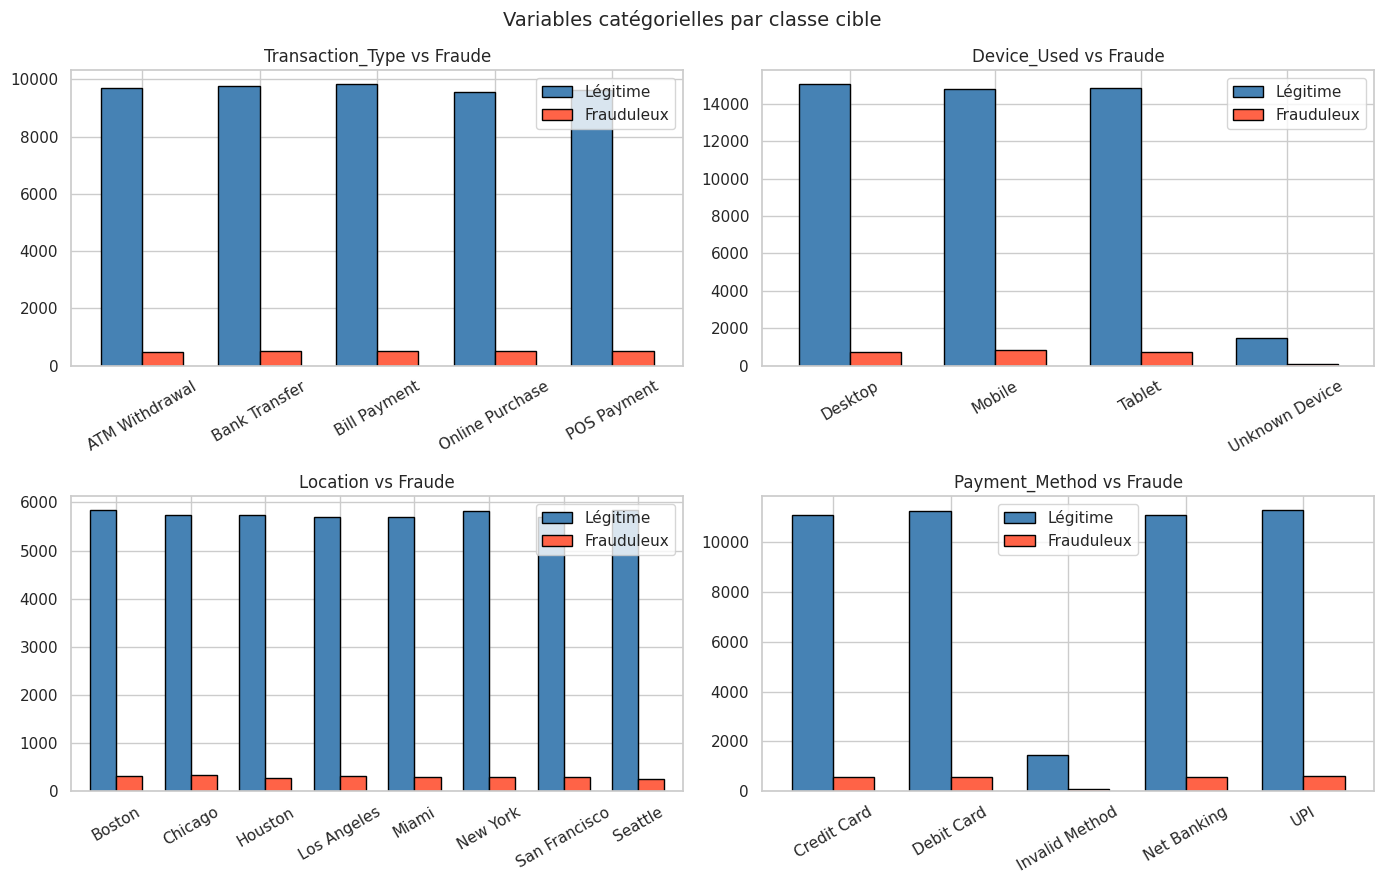

In [14]:
# ──────────────────────────────────────────────
# 3.4 Variables catégorielles
# ──────────────────────────────────────────────
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Fraudulent'])
    ct.columns = ['Légitime', 'Frauduleux']
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='black', width=0.7)
    axes[i].set_title(f'{col} vs Fraude')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend()

plt.suptitle('Variables catégorielles par classe cible', fontsize=14)
plt.tight_layout()
plt.show()

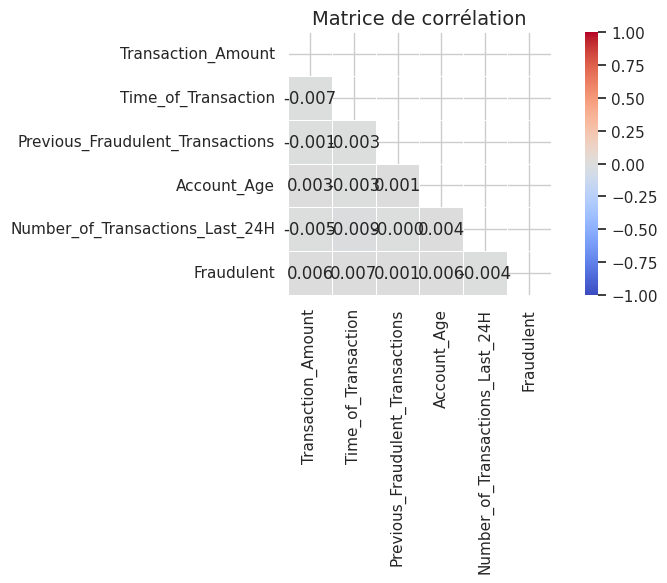


🔗 Corrélations avec la cible :
Time_of_Transaction                 0.007035
Account_Age                         0.006203
Transaction_Amount                  0.005507
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64


In [15]:
# ──────────────────────────────────────────────
# 3.5 Matrice de corrélation (variables numériques)
# ──────────────────────────────────────────────
corr_matrix = df[num_cols + ['Fraudulent']].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Matrice de corrélation', fontsize=14)
plt.tight_layout()
plt.show()

print('\n Corrélations avec la cible :')
print(corr_matrix['Fraudulent'].sort_values(ascending=False).drop('Fraudulent'))

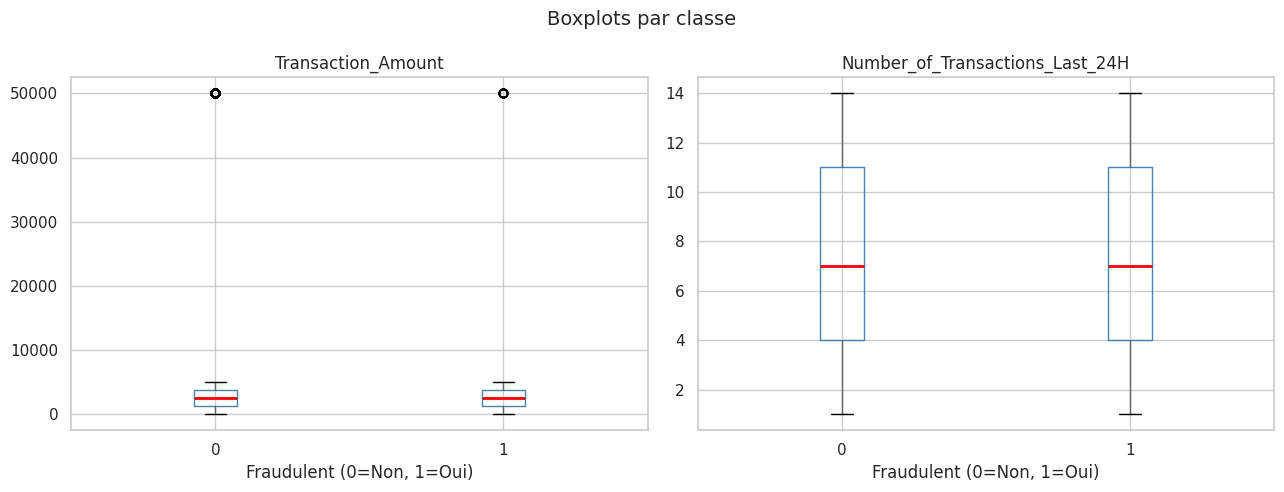

In [16]:
# ──────────────────────────────────────────────
# 3.6 Boxplots – Montant par classe
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['Transaction_Amount', 'Number_of_Transactions_Last_24H']):
    df.boxplot(column=col, by='Fraudulent', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
    ax.set_xlabel('Fraudulent (0=Non, 1=Oui)')

plt.suptitle('Boxplots par classe', fontsize=14)
plt.tight_layout()
plt.show()

---
##  4. Feature Engineering & Transformations

In [17]:
# ──────────────────────────────────────────────
# 4.1 Copie de travail & suppression des identifiants
# ──────────────────────────────────────────────
df_clean = df.drop(columns=['Transaction_ID', 'User_ID']).copy()

print(f'Colonnes conservées : {df_clean.columns.tolist()}')

Colonnes conservées : ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


In [18]:
# ──────────────────────────────────────────────
# 4.2 Gestion des valeurs aberrantes / catégories invalides
# ──────────────────────────────────────────────
# 'Invalid Method' → considéré comme une catégorie suspecte, on la garde
# 'Unknown Device' → on la garde aussi (info utile)

print('Valeurs uniques Payment_Method :', df_clean['Payment_Method'].unique())
print('Valeurs uniques Device_Used    :', df_clean['Device_Used'].unique())

Valeurs uniques Payment_Method : ['Debit Card' 'Credit Card' nan 'UPI' 'Net Banking' 'Invalid Method']
Valeurs uniques Device_Used    : ['Tablet' 'Mobile' 'Desktop' nan 'Unknown Device']


In [19]:
# ──────────────────────────────────────────────
# 4.3 Imputation des valeurs manquantes
# ──────────────────────────────────────────────

# Numérique → médiane (robuste aux outliers)
df_clean = df_clean.assign(
    Transaction_Amount=df_clean['Transaction_Amount'].fillna(df_clean['Transaction_Amount'].median()),
    Time_of_Transaction=df_clean['Time_of_Transaction'].fillna(df_clean['Time_of_Transaction'].median())
)

# Catégorielle → mode
for col in ['Device_Used', 'Location', 'Payment_Method']:
    mode_val = df_clean[col].mode()[0]
    df_clean = df_clean.assign(**{col: df_clean[col].fillna(mode_val)})

print('Valeurs manquantes après imputation :')
print(df_clean.isnull().sum())

Valeurs manquantes après imputation :
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


In [20]:
# ──────────────────────────────────────────────
# 4.4 Création de nouvelles features
# ──────────────────────────────────────────────

# Tranche horaire (matin / après-midi / soir / nuit)
def time_to_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 23:
        return 'evening'
    else:
        return 'night'

df_clean['Time_Slot'] = df_clean['Time_of_Transaction'].apply(time_to_slot)

# Ratio Fraude passée / Age du compte (indicateur de risque)
df_clean['Fraud_Risk_Ratio'] = (
    df_clean['Previous_Fraudulent_Transactions'] /
    (df_clean['Account_Age'] + 1)
)

# Flag haute activité : > 75e percentile de transactions en 24h
q75 = df_clean['Number_of_Transactions_Last_24H'].quantile(0.75)
df_clean['High_Activity'] = (df_clean['Number_of_Transactions_Last_24H'] > q75).astype(int)

# Flag gros montant : > 75e percentile du montant
q75_amount = df_clean['Transaction_Amount'].quantile(0.75)
df_clean['High_Amount'] = (df_clean['Transaction_Amount'] > q75_amount).astype(int)

print(' Nouvelles features créées :')
print(df_clean[['Time_Slot', 'Fraud_Risk_Ratio', 'High_Activity', 'High_Amount']].head())

 Nouvelles features créées :
   Time_Slot  Fraud_Risk_Ratio  High_Activity  High_Amount
0  afternoon          0.000000              1            0
1  afternoon          0.050000              0            0
2  afternoon          0.025862              0            0
3  afternoon          1.000000              0            0
4    evening          0.034483              0            0


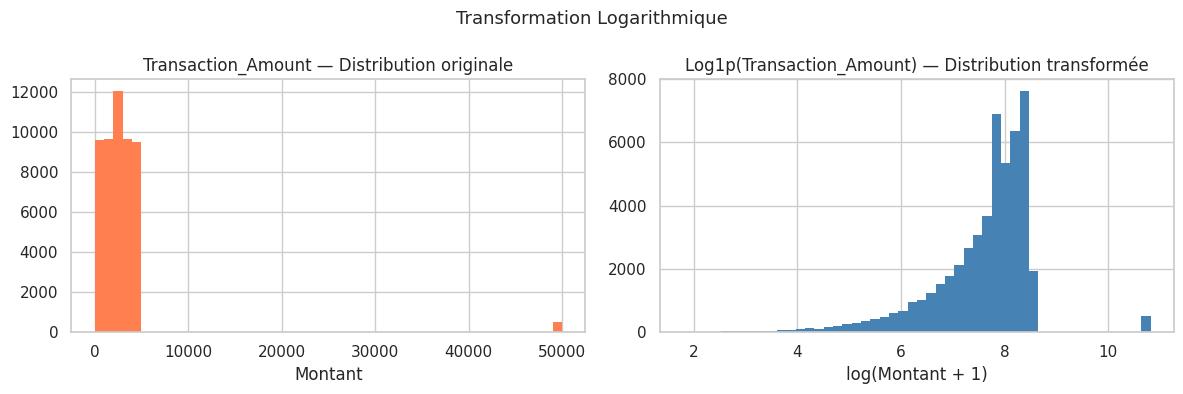

 Log-transform appliqué sur Transaction_Amount


In [21]:
# ──────────────────────────────────────────────
# 4.5 Transformation logarithmique
# ──────────────────────────────────────────────
# Transaction_Amount est très asymétrique → log1p pour normaliser

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['Transaction_Amount'], bins=50, color='coral', edgecolor='none')
axes[0].set_title('Transaction_Amount — Distribution originale')
axes[0].set_xlabel('Montant')

df_clean = df_clean.assign(Log_Transaction_Amount=np.log1p(df_clean['Transaction_Amount']))

axes[1].hist(df_clean['Log_Transaction_Amount'], bins=50, color='steelblue', edgecolor='none')
axes[1].set_title('Log1p(Transaction_Amount) — Distribution transformée')
axes[1].set_xlabel('log(Montant + 1)')

plt.suptitle('Transformation Logarithmique', fontsize=13)
plt.tight_layout()
plt.show()

# Supprimer l'original (remplacé par log)
df_clean = df_clean.drop(columns=['Transaction_Amount'])
print(' Log-transform appliqué sur Transaction_Amount')

In [22]:
# ──────────────────────────────────────────────
# 4.6 Encodage des variables catégorielles
# ──────────────────────────────────────────────
cat_to_encode = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method', 'Time_Slot']

# One-Hot Encoding (drop_first pour éviter la colinéarité)
df_encoded = pd.get_dummies(df_clean, columns=cat_to_encode, drop_first=True, dtype=int)

print(f' Dimensions après encodage : {df_encoded.shape}')
print(f'Colonnes : {df_encoded.columns.tolist()}')

 Dimensions après encodage : (51000, 30)
Colonnes : ['Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Fraudulent', 'Fraud_Risk_Ratio', 'High_Activity', 'High_Amount', 'Log_Transaction_Amount', 'Transaction_Type_Bank Transfer', 'Transaction_Type_Bill Payment', 'Transaction_Type_Online Purchase', 'Transaction_Type_POS Payment', 'Device_Used_Mobile', 'Device_Used_Tablet', 'Device_Used_Unknown Device', 'Location_Chicago', 'Location_Houston', 'Location_Los Angeles', 'Location_Miami', 'Location_New York', 'Location_San Francisco', 'Location_Seattle', 'Payment_Method_Debit Card', 'Payment_Method_Invalid Method', 'Payment_Method_Net Banking', 'Payment_Method_UPI', 'Time_Slot_evening', 'Time_Slot_morning', 'Time_Slot_night']


---
## 5. Rééquilibrage des classes (Oversampling)

In [23]:
X = df_encoded.drop(columns=['Fraudulent'])
y = df_encoded['Fraudulent']

print(f'Distribution avant rééquilibrage :\n{y.value_counts()}')

# Oversampling de la classe minoritaire (Fraudulent=1)
df_majority = df_encoded[df_encoded['Fraudulent'] == 0]
df_minority = df_encoded[df_encoded['Fraudulent'] == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=RANDOM_STATE
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X = df_balanced.drop(columns=['Fraudulent'])
y = df_balanced['Fraudulent']

print(f'\nDistribution après rééquilibrage :\n{y.value_counts()}')
print(f'\nDimensions : X={X.shape}, y={y.shape}')

Distribution avant rééquilibrage :
Fraudulent
0    48490
1     2510
Name: count, dtype: int64

Distribution après rééquilibrage :
Fraudulent
1    48490
0    48490
Name: count, dtype: int64

Dimensions : X=(96980, 29), y=(96980,)


---
## 6. Normalisation & ACP (Analyse en Composantes Principales)

In [24]:
# ──────────────────────────────────────────────
# 6.1 Split Train / Test
# ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Train Fraud rate : {y_train.mean():.4f}')
print(f'Test  Fraud rate : {y_test.mean():.4f}')

Train : (77584, 29) | Test : (19396, 29)
Train Fraud rate : 0.5000
Test  Fraud rate : 0.5000


In [25]:
# ──────────────────────────────────────────────
# 6.2 Standardisation (StandardScaler)
# ──────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Standardisation effectuée')

Standardisation effectuée


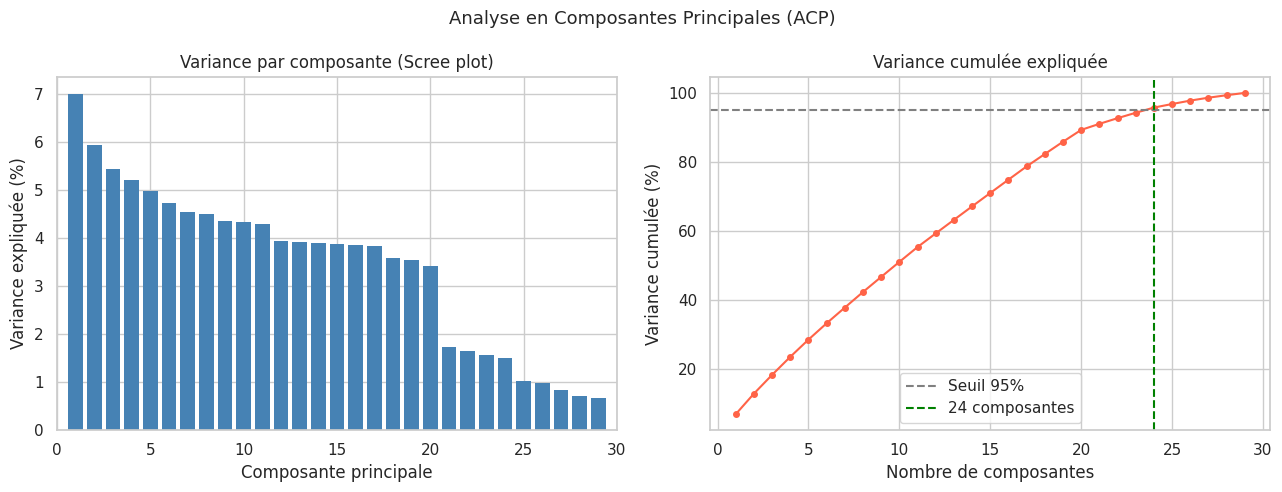


 Nombre de composantes pour 95% de variance : 24


In [26]:
# ──────────────────────────────────────────────
# 6.3 ACP – Analyse en Composantes Principales
# ──────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Variance par composante (Scree plot)')
axes[0].set_xlim([0, 30])

axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'o-', color='tomato', markersize=4)
axes[1].axhline(95, color='gray', linestyle='--', label='Seuil 95%')
axes[1].axvline(n_components_95, color='green', linestyle='--',
                label=f'{n_components_95} composantes')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée expliquée')
axes[1].legend()

plt.suptitle('Analyse en Composantes Principales (ACP)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n Nombre de composantes pour 95% de variance : {n_components_95}')

ACP appliquée : 29 → 24 dimensions


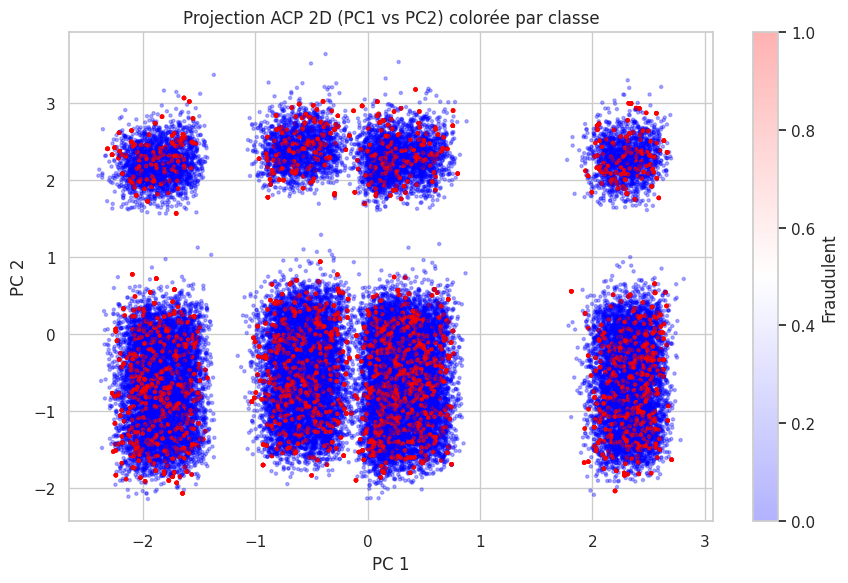

In [27]:
# ──────────────────────────────────────────────
# 6.4 Application de l'ACP (95% variance)
# ──────────────────────────────────────────────
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'ACP appliquée : {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} dimensions')

# Visualisation ACP 2D (PC1 vs PC2) – coloré par classe
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                     c=y_train, cmap='bwr', alpha=0.3, s=5)
plt.colorbar(scatter, ax=ax, label='Fraudulent')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Projection ACP 2D (PC1 vs PC2) colorée par classe')
plt.tight_layout()
plt.show()

---
##  7. Entraînement du Decision Tree Classifier

In [28]:
# ──────────────────────────────────────────────
# 7.1 Modèle de base (baseline)
# ──────────────────────────────────────────────
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline.fit(X_train_pca, y_train)

y_pred_baseline = dt_baseline.predict(X_test_pca)

print(' Modèle baseline – Decision Tree (sans tuning)')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_baseline):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_baseline):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_baseline):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_pred_baseline):.4f}')
print(f'  Profondeur : {dt_baseline.get_depth()}')
print(f'  Feuilles   : {dt_baseline.get_n_leaves()}')

 Modèle baseline – Decision Tree (sans tuning)
  Accuracy  : 0.9686
  Precision : 0.9408
  Recall    : 1.0000
  F1-Score  : 0.9695
  ROC-AUC   : 0.9686
  Profondeur : 67
  Feuilles   : 3307


---
##  8. Cross-Validation (Validation Croisée Stratifiée)

  accuracy     : 0.9596 ± 0.0014
  precision    : 0.9252 ± 0.0025
  recall       : 1.0000 ± 0.0000
  f1           : 0.9611 ± 0.0013
  roc_auc      : 0.9596 ± 0.0014


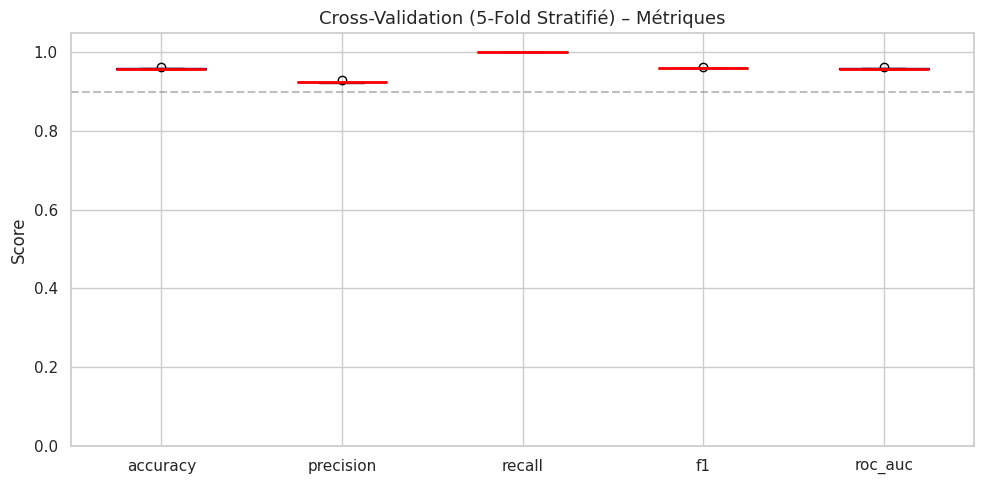

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

metrics_cv = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        X_train_pca, y_train, cv=cv, scoring=metric
    )
    metrics_cv[metric] = scores
    print(f'  {metric:12s} : {scores.mean():.4f} ± {scores.std():.4f}')

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [metrics_cv[m] for m in metrics_cv],
    labels=list(metrics_cv.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)
ax.set_title('Cross-Validation (5-Fold Stratifié) – Métriques', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim([0, 1.05])
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 9. GridSearchCV – Optimisation des Hyperparamètres

In [30]:
param_grid = {
    'criterion'       : ['gini', 'entropy'],
    'max_depth'       : [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 5, 10],
    'class_weight'    : [None, 'balanced']
}

print(f'📐 Nombre de combinaisons : {2*5*4*3*2} configurations × 5 folds = {2*5*4*3*2*5} fits')

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',           # On optimise le F1-score (adapté aux classes déséquilibrées)
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train_pca, y_train)

print(f'\n Meilleurs hyperparamètres :')
for k, v in grid_search.best_params_.items():
    print(f'  {k:22s}: {v}')
print(f'\nMeilleur F1 (CV) : {grid_search.best_score_:.4f}')

📐 Nombre de combinaisons : 240 configurations × 5 folds = 1200 fits
Fitting 5 folds for each of 240 candidates, totalling 1200 fits

 Meilleurs hyperparamètres :
  class_weight          : balanced
  criterion             : gini
  max_depth             : None
  min_samples_leaf      : 1
  min_samples_split     : 5

Meilleur F1 (CV) : 0.9621


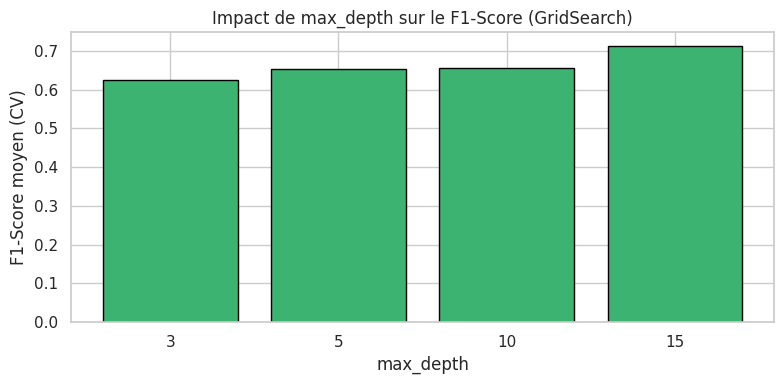

In [31]:
# Visualiser l'impact de max_depth sur le F1
cv_results = pd.DataFrame(grid_search.cv_results_)

depth_f1 = cv_results.groupby('param_max_depth')['mean_test_score'].mean().reset_index()
depth_f1['param_max_depth'] = depth_f1['param_max_depth'].astype(str)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(depth_f1['param_max_depth'], depth_f1['mean_test_score'],
       color='mediumseagreen', edgecolor='black')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1-Score moyen (CV)')
ax.set_title('Impact de max_depth sur le F1-Score (GridSearch)')
plt.tight_layout()
plt.show()

---
##  10. Évaluation du Modèle Final

In [34]:
# ──────────────────────────────────────────────
# 10.1 Prédictions avec le meilleur modèle
# ──────────────────────────────────────────────
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(X_test_pca)
y_proba = best_dt.predict_proba(X_test_pca)[:, 1]

print('=' * 50)
print('   RAPPORT DE CLASSIFICATION (Modèle Final)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Légitime', 'Frauduleux']))

   RAPPORT DE CLASSIFICATION (Modèle Final)
              precision    recall  f1-score   support

    Légitime       1.00      0.94      0.97      9698
  Frauduleux       0.94      1.00      0.97      9698

    accuracy                           0.97     19396
   macro avg       0.97      0.97      0.97     19396
weighted avg       0.97      0.97      0.97     19396



In [35]:
# ──────────────────────────────────────────────
# 10.2 Métriques résumées
# ──────────────────────────────────────────────
results = {
    'Accuracy'  : accuracy_score(y_test, y_pred),
    'Precision' : precision_score(y_test, y_pred),
    'Recall'    : recall_score(y_test, y_pred),
    'F1-Score'  : f1_score(y_test, y_pred),
    'ROC-AUC'   : roc_auc_score(y_test, y_proba),
}

print('\n Métriques du modèle optimisé :')
for metric, val in results.items():
    print(f'  {metric:12s}: {val:.4f}')

# Comparaison Baseline vs Optimisé
print('\nComparaison Baseline vs Optimisé :')
baseline_results = {
    'Accuracy'  : accuracy_score(y_test, y_pred_baseline),
    'F1-Score'  : f1_score(y_test, y_pred_baseline),
    'ROC-AUC'   : roc_auc_score(y_test, y_pred_baseline),
}
compare = pd.DataFrame({'Baseline': baseline_results, 'Optimisé': {k: results[k] for k in baseline_results}})
compare['Amélioration'] = compare['Optimisé'] - compare['Baseline']
print(compare.to_string())


 Métriques du modèle optimisé :
  Accuracy    : 0.9686
  Precision   : 0.9408
  Recall      : 1.0000
  F1-Score    : 0.9695
  ROC-AUC     : 0.9686

Comparaison Baseline vs Optimisé :
          Baseline  Optimisé  Amélioration
Accuracy  0.968550  0.968550           0.0
F1-Score  0.969509  0.969509           0.0
ROC-AUC   0.968550  0.968550           0.0


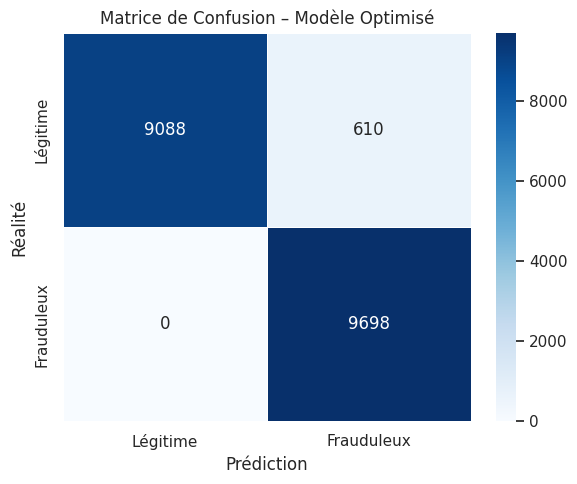

  Vrais Positifs  (TP) : 9,698
  Vrais Négatifs  (TN) : 9,088
  Faux Positifs   (FP) : 610  ← fausses alarmes
  Faux Négatifs   (FN) : 0  ← fraudes non détectées 


In [36]:
# ──────────────────────────────────────────────
# 10.3 Matrice de confusion
# ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Légitime', 'Frauduleux'],
            yticklabels=['Légitime', 'Frauduleux'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Réalité')
ax.set_title('Matrice de Confusion – Modèle Optimisé')
plt.tight_layout()
plt.show()

print(f'  Vrais Positifs  (TP) : {tp:,}')
print(f'  Vrais Négatifs  (TN) : {tn:,}')
print(f'  Faux Positifs   (FP) : {fp:,}  ← fausses alarmes')
print(f'  Faux Négatifs   (FN) : {fn:,}  ← fraudes non détectées ')

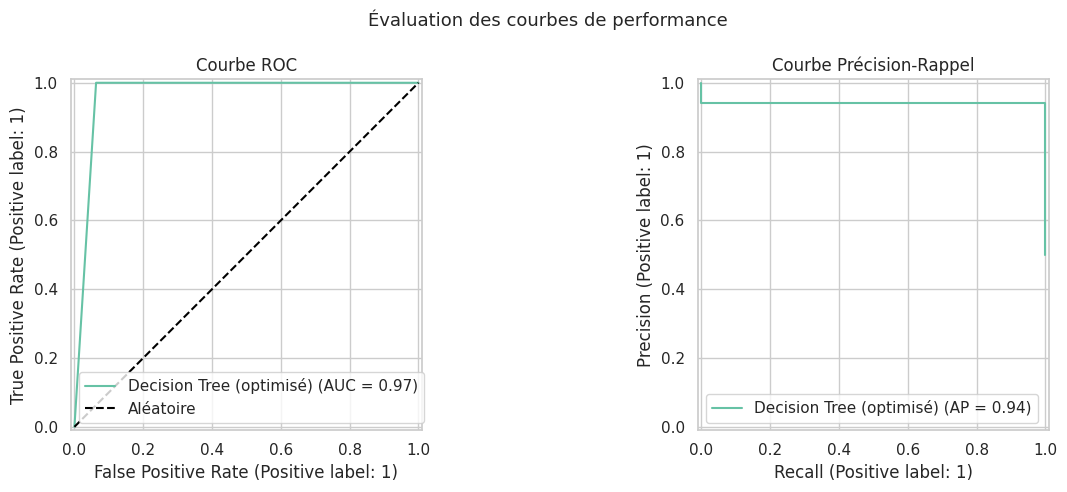

In [37]:
# ──────────────────────────────────────────────
# 10.4 Courbe ROC & Précision-Rappel
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='Decision Tree (optimisé)')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aléatoire')
axes[0].set_title('Courbe ROC')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='Decision Tree (optimisé)')
axes[1].set_title('Courbe Précision-Rappel')

plt.suptitle('Évaluation des courbes de performance', fontsize=13)
plt.tight_layout()
plt.show()

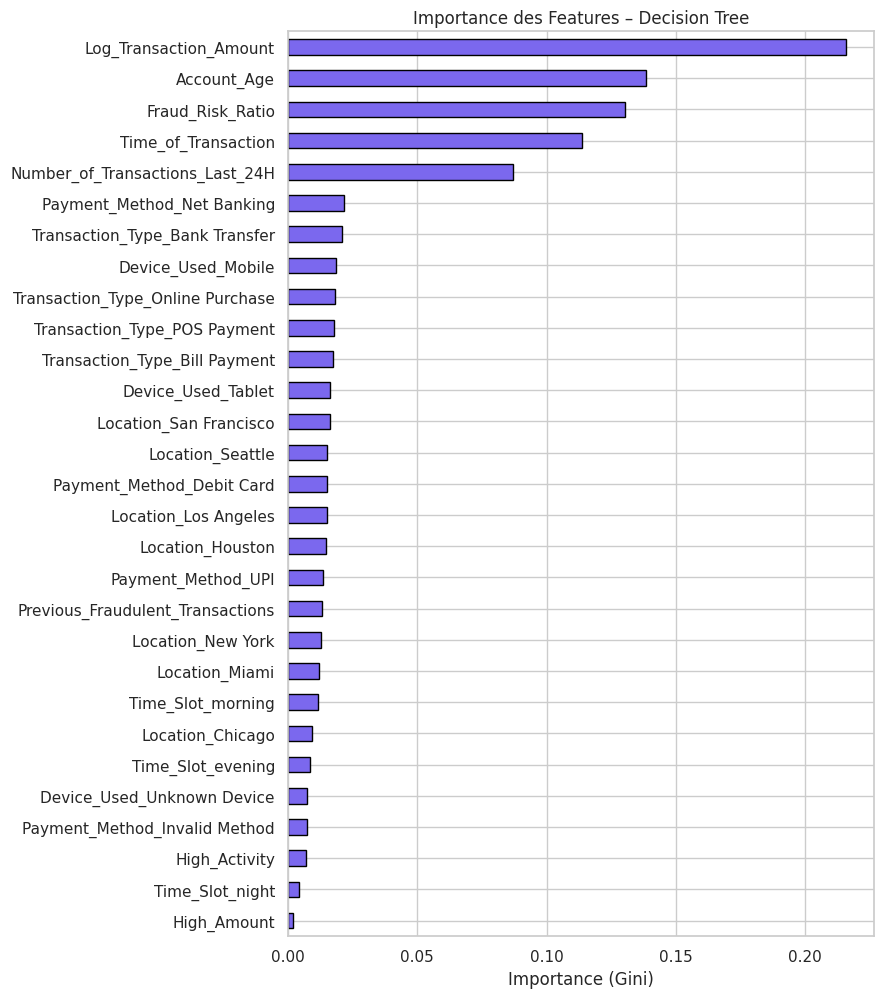


 Top 10 features :
Log_Transaction_Amount              0.215963
Account_Age                         0.138473
Fraud_Risk_Ratio                    0.130478
Time_of_Transaction                 0.113912
Number_of_Transactions_Last_24H     0.086930
Payment_Method_Net Banking          0.021741
Transaction_Type_Bank Transfer      0.020697
Device_Used_Mobile                  0.018335
Transaction_Type_Online Purchase    0.018043
Transaction_Type_POS Payment        0.017600


In [38]:
# ──────────────────────────────────────────────
# 10.5 Importance des features
# ──────────────────────────────────────────────
# Pour le Decision Tree optimisé (avant ACP, pour lisibilité)
dt_no_pca = DecisionTreeClassifier(**grid_search.best_params_, random_state=RANDOM_STATE)
dt_no_pca.fit(X_train, y_train)

feat_imp = pd.Series(dt_no_pca.feature_importances_, index=X.columns)
feat_imp = feat_imp[feat_imp > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(feat_imp)*0.35)))
feat_imp.plot(kind='barh', ax=ax, color='mediumslateblue', edgecolor='black')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Importance des Features – Decision Tree')
plt.tight_layout()
plt.show()

print('\n Top 10 features :')
print(feat_imp.sort_values(ascending=False).head(10).to_string())

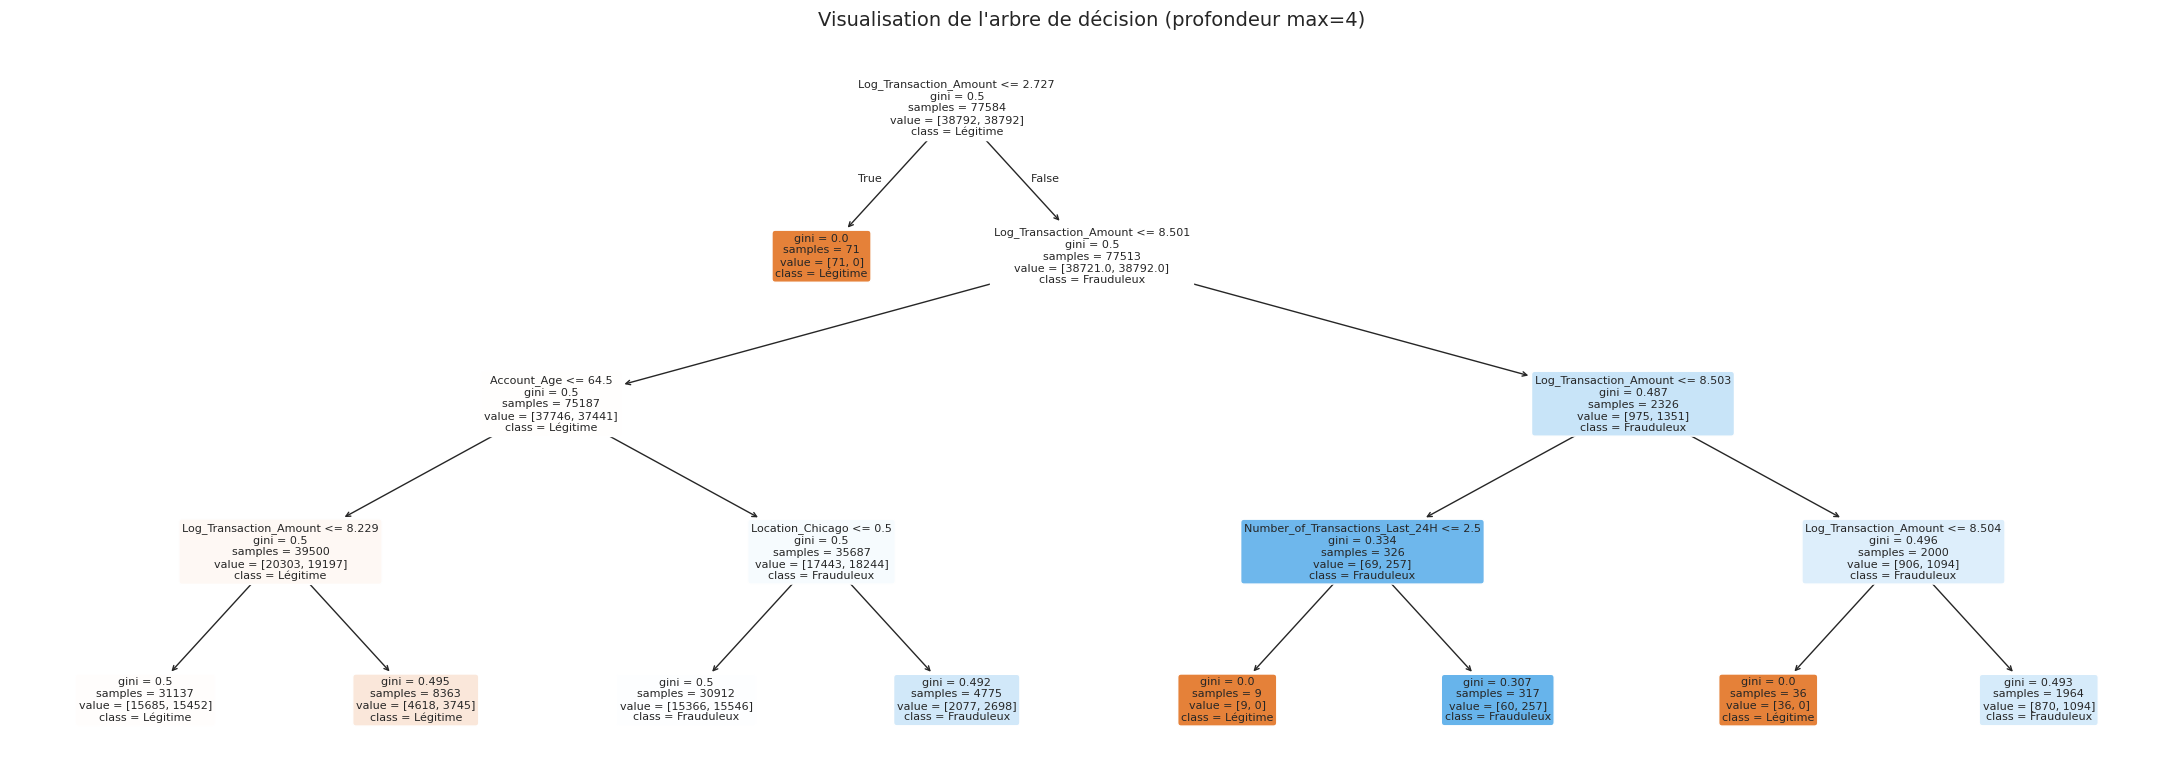

In [39]:
# ──────────────────────────────────────────────
# 10.6 Visualisation de l'arbre (depth limité)
# ──────────────────────────────────────────────
dt_visual = DecisionTreeClassifier(
    max_depth=4,
    criterion=grid_search.best_params_['criterion'],
    random_state=RANDOM_STATE
)
dt_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_visual,
    feature_names=X.columns,
    class_names=['Légitime', 'Frauduleux'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,
    ax=ax
)
ax.set_title('Visualisation de l\'arbre de décision (profondeur max=4)', fontsize=14)
plt.tight_layout()
plt.show()